In [1]:
# Cell 1:
import networkx as nx
import numpy as np
from queue import PriorityQueue
import ipywidgets as widgets
from copy import deepcopy
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, defaultdict
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, HTML
import logging
import dgl 
import os 
import random 
import itertools
from utils.model_utils import *

# Giả định basic_utils.py chứa MỌI THỨ từ file Original_loop.ipynb
# (MultiHeadDQN, NetworkEnv, ReplayBuffer, evaluate_model, v.v.)
from utils.attack_algo_utils import *
from utils.graph_utils import *
from utils.basic_utils import *

# --- CUDA DEVICE SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

def disable_edge_weights_ui(graph):
    """
    Interface to select an edge and set its weights (user, root) to -1.0
    instead of removing the edge from the graph entirely.
    """

    output_disable = widgets.Output()
    all_nodes = list(graph.nodes())

    if not all_nodes:
        print("Graph is empty.")
        return

    # --- Widgets ---
    source_dropdown = widgets.Dropdown(
        options=all_nodes,
        description='Source Node:',
        style={'description_width': 'initial'}
    )

    target_dropdown = widgets.Dropdown(
        options=[],
        description='Target Node:',
        style={'description_width': 'initial'},
        disabled=True
    )

    # Button to set weights to -1
    btn_disable = widgets.Button(
        description='Set Weight -1',
        button_style='warning', # Orange color
        icon='eraser'
    )

    # --- Logic ---
    def on_source_change(change):
        if change['type'] == 'change' and change['name'] == 'value':
            u = change['new']
            if u in graph:
                # Get the list of nodes that u points to
                neighbors = list(graph.neighbors(u))
                if neighbors:
                    target_dropdown.options = neighbors
                    target_dropdown.disabled = False
                    target_dropdown.value = neighbors[0]
                else:
                    target_dropdown.options = []
                    target_dropdown.disabled = True

    def on_disable_click(b):
        with output_disable:
            clear_output(wait=True)
            u = source_dropdown.value
            v = target_dropdown.value

            if u is None or v is None:
                display(HTML("<b>Error:</b> Please select nodes."))
                return

            if graph.has_edge(u, v):
                # --- MAIN LOGIC ---
                # Instead of remove_edge, we update attributes to -1.0
                graph[u][v]['user'] = -1.0
                graph[u][v]['root'] = -1.0

                # Re-check to confirm
                new_data = graph[u][v]

                msg = (f"<b>Updated:</b> Edge '{u}' &rarr; '{v}' weights set to -1.0.<br>"
                       f"<i>Current attributes: {new_data}</i>")
                logger.info(f"Set weights to -1.0 for edge ({u}, {v})")
                display(HTML(msg))
            else:
                display(HTML(f"<b>Error:</b> Edge ({u}, {v}) not found."))

    # --- Wiring ---
    source_dropdown.observe(on_source_change, names='value')
    btn_disable.on_click(on_disable_click)

    # Init
    if all_nodes:
        # Initial trigger
        on_source_change({'type': 'change', 'name': 'value', 'new': all_nodes[0]})

    display(HTML("<h3>Disable Edge Interface (Set Weights = -1.0)</h3>"))
    display(source_dropdown, target_dropdown, btn_disable, output_disable)

# Run the interface
# disable_edge_weights_ui(G_new)

In [4]:
# Cell 3: Load graph from graph_environment.pth instead of redefining it

# Path to the environment file saved in Original_loop.ipynb
# Note: Check experiment_id again if you changed it in Original_loop.ipynb (default is '1')
experiment_id = 1
graph_env_path = f'graphs/{experiment_id}/graph_environment.pth'

if os.path.exists(graph_env_path):
    print(f"Loading graph from: {graph_env_path}")

    # Load data using torch
    # weights_only=False is necessary because we are loading the full NetworkX graph structure
    env_data = torch.load(graph_env_path, map_location=device, weights_only=False)

    # Retrieve the saved original graph (key is 'G' as defined in the save_graph_env function)
    G_1 = env_data['G']

    print(f"Successfully loaded G_1: {G_1.number_of_nodes()} nodes, {G_1.number_of_edges()} edges")

    # (Optional) Check if important attributes exist
    # print("Node attributes:", G_1.nodes(data=True))
else:
    raise FileNotFoundError(f"File not found: {graph_env_path}. Please run 'save_graph_env' in Original.ipynb first.")

# Create a copy to add new nodes for the Bias Correction section
G_new = G_1.copy()

Dang tai do thi tu: graphs/1/graph_environment.pth
Load thanh cong G_1: 8 nodes, 56 edges


In [5]:
# Edit new graph
# add_node_with_edges(G_new, "New node")
disable_edge_weights_ui(G_new)

Dropdown(description='Source Node:', options=('Data Server', 'Pad', 'Web Server', 'Host 1', 'Host 2', 'Host 3'…

Dropdown(description='Target Node:', options=('File Server', 'Router', 'Pad', 'Web Server', 'Host 1', 'Host 2'…

Button(button_style='warning', description='Set Weight -1', icon='eraser', style=ButtonStyle())

Output()

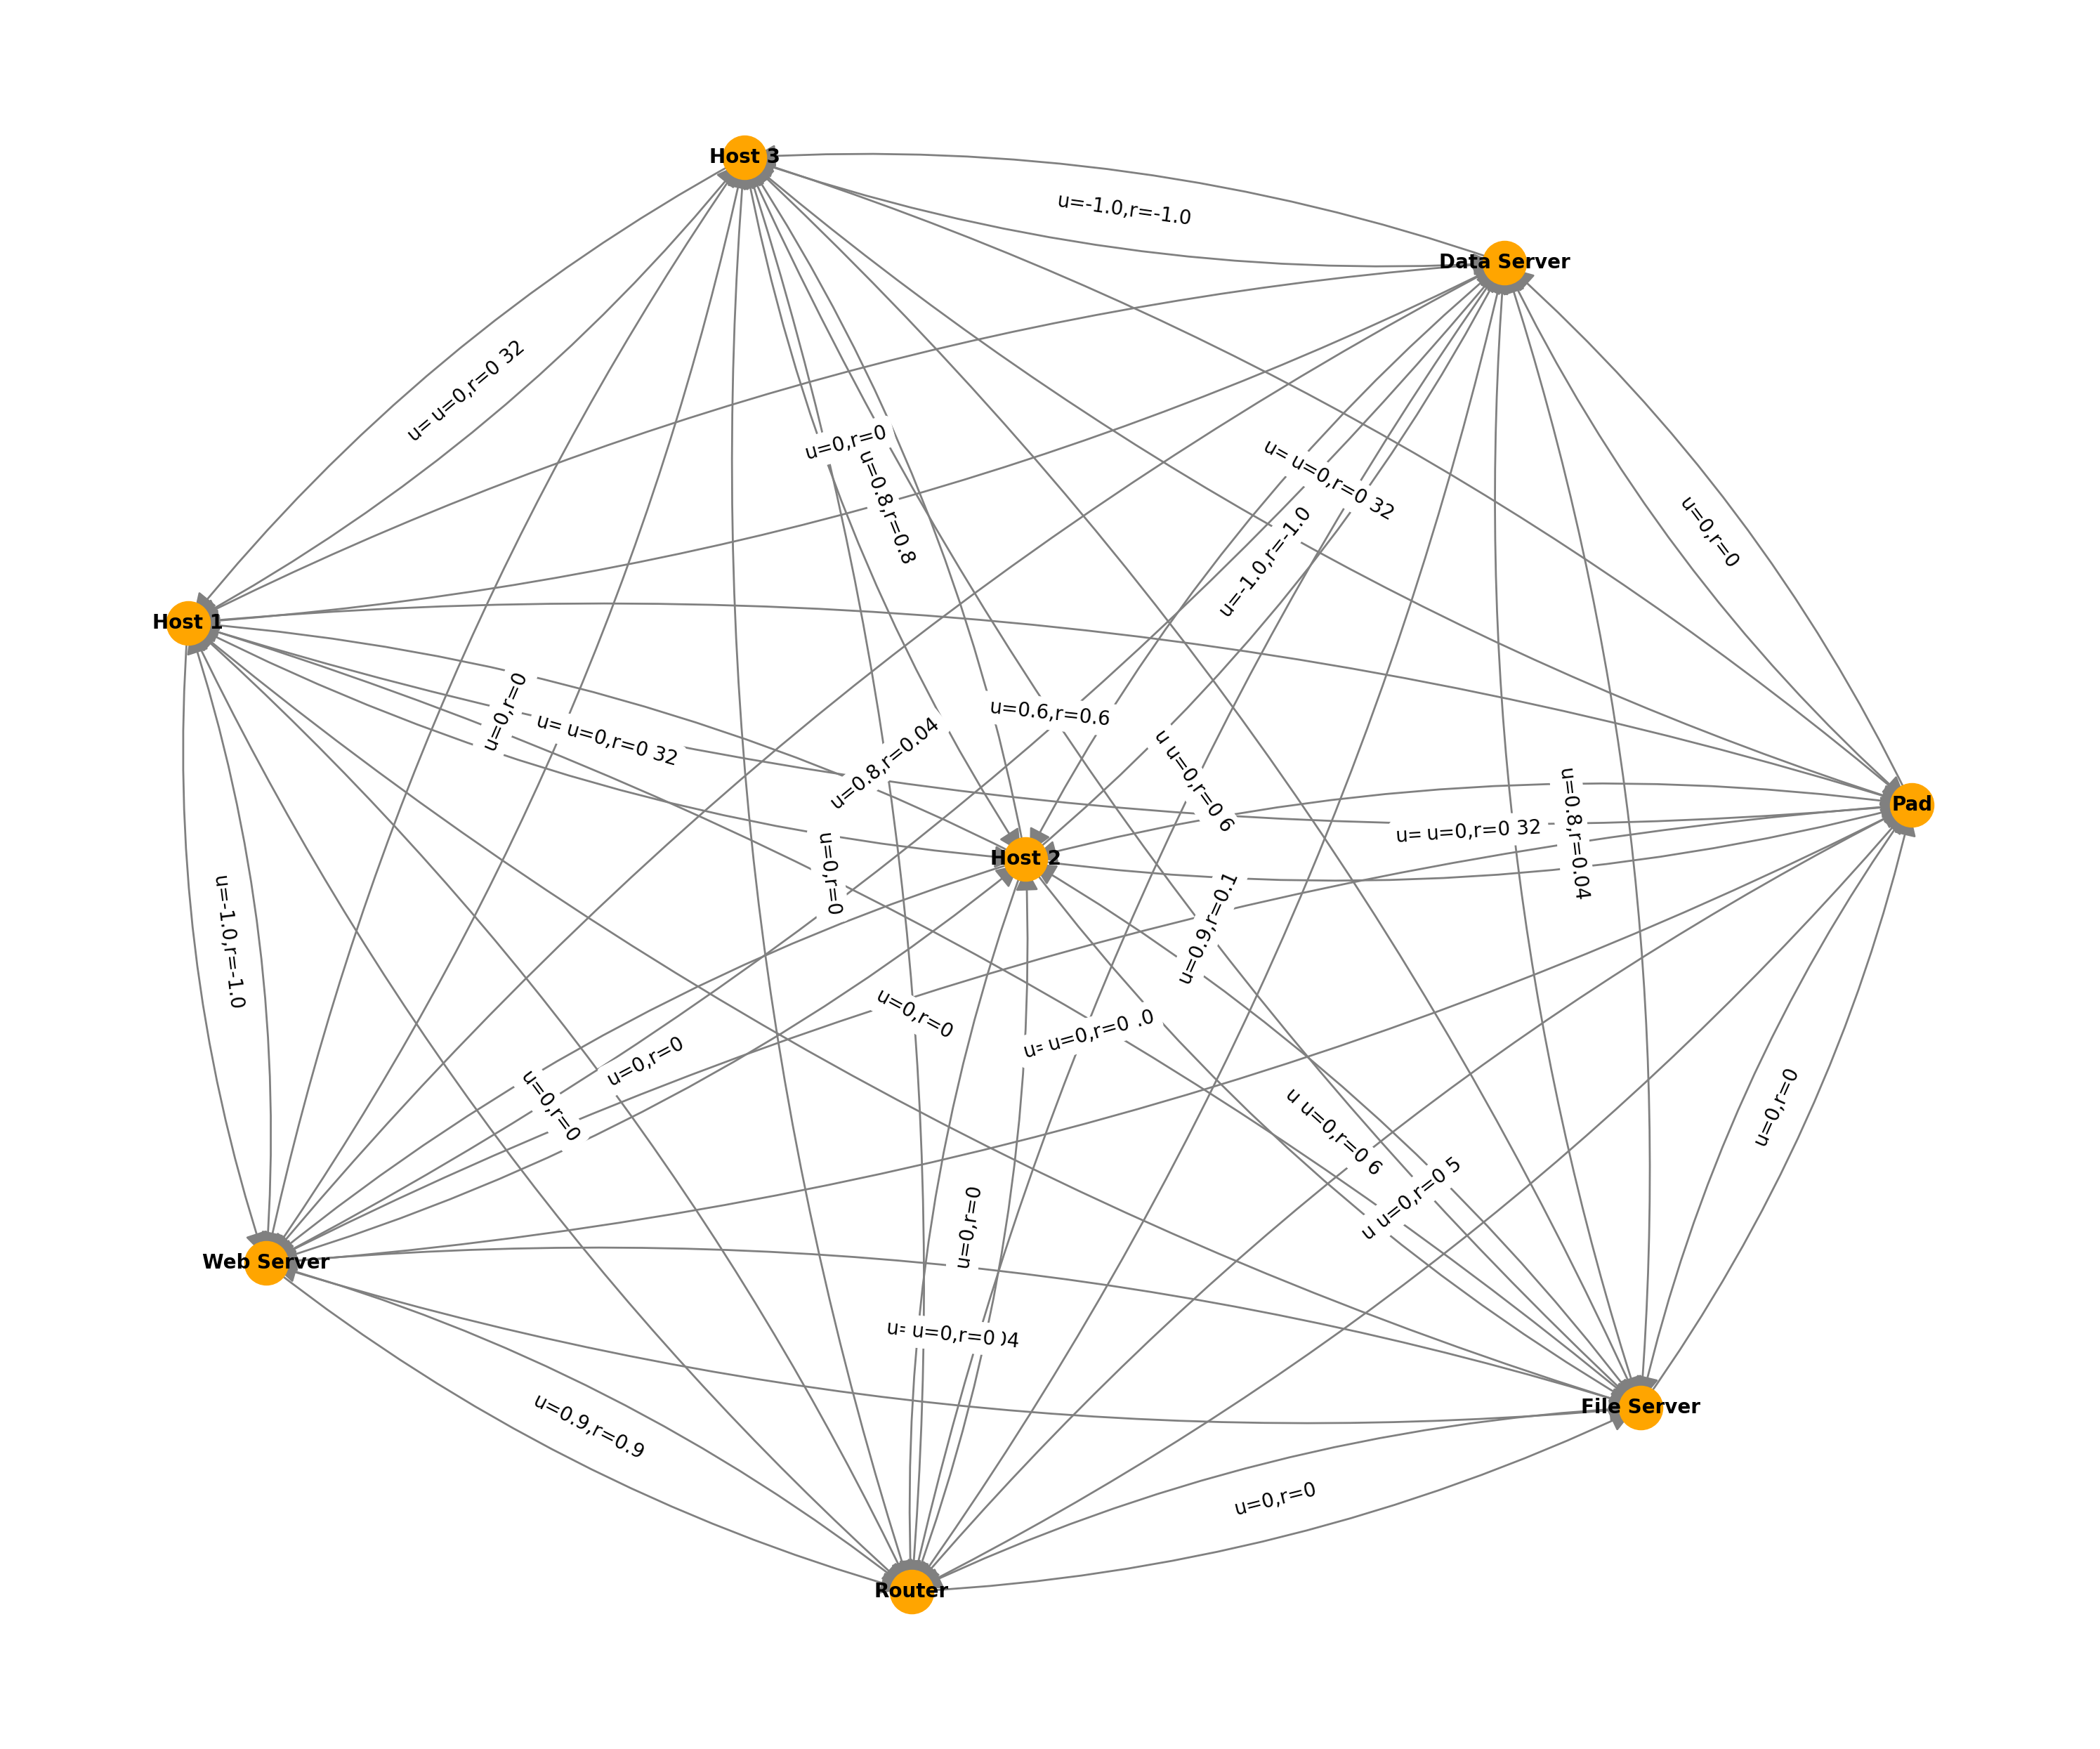

In [6]:
# Cell 4:
plt.figure(figsize=(30, 25))

# Fix the layout so it's consistent every time
pos = nx.spring_layout(G_new, seed=42)

# Draw the nodes
nx.draw_networkx_nodes(G_new, pos, node_color='orange', node_size=2000)

# Draw node labels
nx.draw_networkx_labels(G_new, pos, font_size=20, font_weight='bold')

# Draw edges with arrows and gray color
nx.draw_networkx_edges(
    G_new, pos,
    edge_color='gray',
    arrows=True,
    arrowsize=50,
    width=2,
    connectionstyle='arc3,rad=0.1'  # Add a slight curve to the edges for the aesthetic
)

# Draw edge weight labels
edge_labels = {(u, v): f"u={d['user']},r={d['root']}" for u, v, d in G_new.edges(data=True)}
nx.draw_networkx_edge_labels(G_new, pos, edge_labels=edge_labels, font_size=20)

plt.axis('off')
plt.tight_layout()

plt.savefig("graph_new.png") # Change filename to avoid overwriting
plt.show()

In [7]:
# Cell 5: Load Configuration and GNN Encoder (Synced with Graph.ipynb)
import yaml
import torch
import torch.nn.functional as F
from utils.graph_utils import EGraphSAGE, DGI # Assuming class is located here

print("\n--- Loading GNN configuration and weights ---")

# --- 1. Define Paths (Matches Graph.ipynb cell 10) ---
BASE_PATH = 'graphs'
OLD_EXP_ID = 1
MODEL_STATE_PATH = f"{BASE_PATH}/dgi_model_state_dict.pth"
CONFIG_FILE_PATH = f"{BASE_PATH}/model_config.yaml"
OLD_DQN_PATH = f"{BASE_PATH}/{OLD_EXP_ID}/dqn_model.pth"

# This file contains original data from Graph.ipynb (old node features)
# Note: Ensure this file exists or is retrieved from Graph.ipynb logic
STATIC_ENV_PATH = f"{BASE_PATH}/{OLD_EXP_ID}/graph_environment.pth"

# --- 2. LOAD GNN MODEL ---
try:
    # Load Config
    with open(CONFIG_FILE_PATH, 'r') as f:
        config = yaml.safe_load(f)
    print(f"Loaded GNN Config: {config}")

    # Initialize Encoder
    encoder = EGraphSAGE(
        config['NDIM_IN'],
        config['EDIM'],
        config['N_HIDDEN'],
        config['N_OUT'],
        config['N_LAYERS'],
        F.leaky_relu,
        device
    )

    # Load weights
    dgi_model_to_load = DGI(encoder)
    # weights_only=False to avoid warnings on newer PyTorch versions; map_location to prevent device errors
    dgi_model_to_load.load_state_dict(torch.load(MODEL_STATE_PATH, map_location=device, weights_only=False))

    # Extract Encoder & Freeze (crucial for RL)
    trained_encoder = dgi_model_to_load.encoder
    trained_encoder.to(device)
    trained_encoder.eval() # Inference mode
    for param in trained_encoder.parameters():
        param.requires_grad = False # Do not retrain GNN during RL training

    # Set environment parameters
    embedding_dim = config['N_OUT']
    MAX_N_FEATURES = config['NDIM_IN']
    MAX_E_FEATURES = config['EDIM']

    # Preprocessing function (Required for NetworkEnv)
    def build_batch_tensor(feats, max_dim):
        return feats[:, :max_dim]

    print(f"[SUCCESS] GNN encoder loaded. Embedding dim: {embedding_dim}")

    if os.path.exists(OLD_DQN_PATH):
        print(f"[NOTICE] Old DQN model found at: {OLD_DQN_PATH}")
    else:
        print(f"[WARNING] Old DQN model file not found at: {OLD_DQN_PATH}")

except Exception as e:
    print(f"\n[ERROR] Problem loading GNN encoder: {e}")
    trained_encoder = None


--- Đang tải cấu hình và trọng số GNN ---
Loaded GNN Config: {'EDIM': 2, 'NDIM_IN': 2, 'N_HIDDEN': 16, 'N_LAYERS': 2, 'N_OUT': 24}
[THÀNH CÔNG] Đã tải GNN encoder. Embedding dim: 24
[THÔNG BÁO] Tìm thấy DQN model cũ tại: graphs/1/dqn_model.pth


In [8]:
# Cell 7: Setup New Environment & Transfer Learning (Modified)
from copy import deepcopy
import dgl
import torch
import numpy as np

# --- 1. Load OLD environment data ---
# Necessary to identify the previous mapping
try:
    # Using STATIC_ENV_PATH defined in Cell 5
    env_data = torch.load(STATIC_ENV_PATH, weights_only=False)
    node_map_static = env_data['node_map']
except Exception:
    print("Warning: Could not load old node map. Falling back to default.")
    node_map_static = {}

# --- 2. Process New Graph (G_new from Cell 3) ---
# G_new already contains the "New node"

# 2.1. Update Node Map
node_map_new = node_map_static.copy()
new_nodes_list = []

# Iterate through all nodes in G_new to find new ones
for node in G_new.nodes():
    if node not in node_map_new:
        new_idx = len(node_map_new)
        node_map_new[node] = new_idx
        new_nodes_list.append(node)

M_old = len(node_map_static)
M_new = len(node_map_new)

print(f"New Node Map (M={M_new}): {node_map_new}")
print(f"Newly added nodes: {new_nodes_list}")

# 2.2. Create Feature Tensor (GNN Normalized)
# Retrieve node list in the exact order of the new indices
node_order_new = [None] * M_new
for name, idx in node_map_new.items():
    node_order_new[idx] = name

# Create node feature tensor [State, Priority]
nfeats_list = []
for node in node_order_new:
    # Get attribute from G_new, default to 0 if missing
    state = G_new.nodes[node].get('state', 0.0)
    prio = G_new.nodes[node].get('priority', 0.0)
    nfeats_list.append([state, prio])

nfeats_new = torch.tensor(nfeats_list, dtype=torch.float32).to(device)
# Trim if feature dim > model config (e.g., model only accepts first 2 features)
nfeats_new = build_batch_tensor(nfeats_new, MAX_N_FEATURES)

# Create edge feature tensor
src_ids = []
dst_ids = []
efeats_list = []

# Step 1: Extract all edges into a list
raw_edges = list(G_new.edges(data=True))

# Step 2: Sort edges by timestamp (identical to logic in basic_utils.py)
# Use .get('timestamp', 0.0) to avoid errors if old edges lack timestamps
raw_edges.sort(key=lambda x: x[2].get('timestamp', 0.0))

print(f"Processing {len(raw_edges)} edges (sorted by timestamp)...")

# Step 3: Iterate through sorted list to create DGL graph
for u, v, data in raw_edges:
    src_ids.append(node_map_new[u])
    dst_ids.append(node_map_new[v])
    efeats_list.append([data.get('user', 0.0), data.get('root', 0.0)])

g_dgl_new = dgl.graph((src_ids, dst_ids), num_nodes=M_new).to(device)

if efeats_list:
    efeats_new = torch.tensor(efeats_list, dtype=torch.float32).to(device)
    efeats_new = build_batch_tensor(efeats_new, MAX_E_FEATURES)
else:
    # Handle case with no edges (rare)
    efeats_new = torch.zeros((0, MAX_E_FEATURES)).to(device)


# --- 3. Initialize New Environment ---
# Crucial: Keep max_nodes and max_edges the same as the original training
# to ensure the DQN input size remains constant (due to padding)
N_honeypots = 2
MAX_NODES_CONFIG = 24 # From config or hardcoded if known beforehand
MAX_EDGES_CONFIG = 256

env = NetworkEnv(
    G_new=G_new,
    attack_fn=global_weighted_random_attack, # Attack function from utils
    g_dgl=g_dgl_new,
    encoder=trained_encoder, # Encoder loaded and frozen in Cell 5
    original_node_features=nfeats_new,
    original_edge_features=efeats_new,
    node_map=node_map_new,
    num_honeypots=N_honeypots,
    max_nodes=MAX_NODES_CONFIG,
    max_edges=MAX_EDGES_CONFIG
)

print("\n[ENVIRONMENT] New Env initialized.")
print(f"Actual node count: {M_new}. Max padding: {MAX_NODES_CONFIG}")


# --- 4. Transfer Learning: Load Old DQN Model ---
# Calculate input state size (based on fixed padding)
# State = [Flattened Node Embeddings] + [Flattened Edge Embeddings]
# Dimension = (max_nodes * embed_dim) + (max_edges * embed_dim)
# Note: Must match logic in NetworkEnv._get_embeddings_from_state
state_size_fixed = (MAX_NODES_CONFIG * embedding_dim) + (MAX_EDGES_CONFIG * embedding_dim)

# Initialize model with fixed dimensions (matching previous training)
# Action output remains MAX_NODES_CONFIG (24), but we'll mask nodes > M_new
dqn_model = MultiHeadDQN(state_size_fixed, N_honeypots, MAX_NODES_CONFIG).to(device)

try:
    # OLD_DQN_PATH defined in Cell 5
    checkpoint = torch.load(OLD_DQN_PATH, map_location=device, weights_only=False)

    # Load state dict
    # If the checkpoint includes the optimizer, only extract 'policy_net_state_dict'
    if 'policy_net_state_dict' in checkpoint:
        dqn_model.load_state_dict(checkpoint['policy_net_state_dict'])
    else:
        dqn_model.load_state_dict(checkpoint)

    print(f"[TRANSFER] Weights loaded from: {OLD_DQN_PATH}")
except Exception as e:
    print(f"[ERROR] Could not load old model: {e}")
    # If error occurs, dqn_model defaults to random initialization

Node Map Mới (M=8): {'Data Server': 0, 'Pad': 1, 'Web Server': 2, 'Host 1': 3, 'Host 2': 4, 'Host 3': 5, 'File Server': 6, 'Router': 7}
Các node mới thêm vào: []
Đang xử lý 56 cạnh (đã sort theo timestamp)...
node_to_idx đã được tải: {'Data Server': 0, 'Pad': 1, 'Web Server': 2, 'Host 1': 3, 'Host 2': 4, 'Host 3': 5, 'File Server': 6, 'Router': 7}
Mục tiêu (Goals) được thiết lập: ['Data Server']
Số lượng honeypot (N) được thiết lập: 2
Số lượng nút đặt (M) được thiết lập: 8

[MÔI TRƯỜNG] Đã khởi tạo Env mới.
Số node thực tế: 8. Max padding: 24
[TRANSFER] Đã tải trọng số từ: graphs/1/dqn_model.pth


In [9]:
def train_dqn_finetune(
    env,
    policy_net,
    target_net,
    optimizer,
    replay_buffer,
    num_episodes,
    device=None,
    batch_size=64,
    gamma=0.99,
    tau=0.005,
    freeze_encoder_steps=2000,
    stability_coef=0.1
):
    """
    Fine-tune DQN after loading a pre-trained model.

    - policy_net, target_net, optimizer, replay_buffer -> passed from outside.
    - Maintains Q-value stability using stability loss (if enabled).
    - Temporarily freeze encoder to avoid "shocks" from input graph changes.
    """

    global best_checkpoint, best_episode

    # Ensure everything is on the correct device
    policy_net = policy_net.to(device)
    target_net = target_net.to(device)
    target_net.eval()

    total_reward = 0
    dsp = 0
    best_dsp = 0
    best_checkpoint = None
    global_step = 0

    interval_check = max(1, num_episodes // 10)
    interval_save = max(1, num_episodes // 5)

    for episode in range(1, num_episodes + 1):

        state = env.reset().to(device)
        done = False
        current_num_nodes = len(env.nodes)

        while not done:

            # -------------------------
            # ACTION SELECTION
            # -------------------------
            with torch.no_grad():
                state_tensor = state.flatten().unsqueeze(0)
                q_values = policy_net(state_tensor)

                # Mask nodes outside the current graph topology
                if current_num_nodes < q_values.shape[-1]:
                    q_values[:, :, current_num_nodes:] = -float("inf")

                action = select_action_multi_head(q_values.squeeze(0), current_num_nodes)

            # STEP
            next_state, reward, done, path, captured = env.step(action)
            next_state = next_state.to(device)

            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            if reward == 1:
                dsp += 1
            global_step += 1

            # -------------------------
            # TRAINING STEP
            # -------------------------
            if len(replay_buffer) >= batch_size:

                states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

                states = states.to(device).flatten(start_dim=1)
                next_states = next_states.to(device).flatten(start_dim=1)
                actions = actions.to(device)
                rewards = rewards.to(device)
                dones = dones.to(device)

                # 1. CALCULATE CURRENT Q(s,a)
                q_values_all = policy_net(states)
                current_q = (q_values_all * actions).sum(dim=2).sum(dim=1)

                # 2. CALCULATE DOUBLE DQN TARGET
                #
                with torch.no_grad():
                    # Use Policy Net to select the best action (Selection)
                    next_policy_q = policy_net(next_states)

                    if current_num_nodes < next_policy_q.shape[-1]:
                        next_policy_q[:, :, current_num_nodes:] = -float("inf")

                    next_act = next_policy_q.argmax(dim=2, keepdim=True)

                    # Use Target Net to evaluate the value of those actions (Evaluation)
                    next_target_q = target_net(next_states).gather(2, next_act).squeeze(2)

                    next_q_total = next_target_q.sum(dim=1)
                    targets = rewards.squeeze(1) + (1 - dones.squeeze(1)) * gamma * next_q_total

                # 3. CALCULATE LOSS
                # Note: Stability loss can be uncommented if Q-values fluctuate too much
                # with torch.no_grad():
                #     old_q = target_net(states)
                # stability_loss = stability_coef * nn.MSELoss()(q_values_all, old_q)

                loss = nn.MSELoss()(current_q, targets)

                # 4. BACKPROPAGATION
                optimizer.zero_grad()
                loss.backward()
                # Clip gradients to prevent "exploding gradients" during fine-tuning
                torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
                optimizer.step()

                # 5. SOFT UPDATE TARGET NETWORK (Polyak Averaging)
                #
                for t, p in zip(target_net.parameters(), policy_net.parameters()):
                    t.data.copy_(t.data * (1 - tau) + p.data * tau)

        # LOGGING
        if episode % interval_check == 0:
            print(f"[FineTune] Episode {episode}, Total Reward={total_reward}, DSP={dsp / interval_check * 100:.2f}%")
            total_reward = 0

            # Track best checkpoint based on Defense Success Probability (DSP)
            if dsp > best_dsp:
                best_dsp = dsp
                best_episode = episode
                best_checkpoint = {
                    "policy_net_state_dict": deepcopy(policy_net.state_dict()),
                    "target_net_state_dict": deepcopy(target_net.state_dict()),
                    "optimizer_state_dict": deepcopy(optimizer.state_dict()),
                }

            dsp = 0

        # SAVE CHECKPOINT
        if (episode + 1) % interval_save == 0 and best_checkpoint is not None:
            os.makedirs("./Saved_Model", exist_ok=True)
            torch.save(
                {
                    "policy_net_state_dict": best_checkpoint["policy_net_state_dict"],
                    "target_net_state_dict": best_checkpoint["target_net_state_dict"],
                    "optimizer_state_dict": best_checkpoint["optimizer_state_dict"],
                    "episode": best_episode,
                },
                "./Saved_Model/dqn_finetuned.pth",
            )
            print(f"Saved finetuned model. Best DSP={best_dsp}")
            best_dsp = 0
            best_checkpoint = None

    return policy_net

In [10]:
optimizer = optim.Adam(dqn_model.parameters(), lr=0.0005)
replay_buffer = ReplayBuffer(capacity=4000)

model = train_dqn_finetune(env, dqn_model, dqn_model,optimizer, replay_buffer,256, device )

tensor([[-0.0039, -0.0034, -0.0032,  ...,  0.7778, -0.0039,  0.7141],
        [-0.0043, -0.0041, -0.0034,  ...,  0.8442, -0.0043,  0.7956],
        [-0.0043, -0.0041, -0.0034,  ...,  0.8442, -0.0043,  0.7956],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
       device='cuda:0')
[FineTune] Episode 25, Total Reward=5, DSP=60.00%
[FineTune] Episode 50, Total Reward=-1, DSP=48.00%
Saved finetuned model. Best DSP=15
[FineTune] Episode 75, Total Reward=7, DSP=64.00%
[FineTune] Episode 100, Total Reward=-3, DSP=44.00%
Saved finetuned model. Best DSP=16
[FineTune] Episode 125, Total Reward=-9, DSP=32.00%
[FineTune] Episode 150, Total Reward=1, DSP=52.00%
Saved finetuned model. Best DSP=13
[FineTune] Episode 175, Total Reward=1, DSP=52.00%
[FineTune] Episode 200, Total Reward=7, DSP=64.00%
Saved finetuned model. Best D

In [11]:
# Cell 14:
# Final evaluation
print("\n--- Đánh giá Model sau khi hiệu chỉnh Bias ---")
evaluate_model(model, env, num_episodes=1000, device=device)


--- Đánh giá Model sau khi hiệu chỉnh Bias ---
Đang đánh giá trên device: cuda
Đang đánh giá... Kiến trúc Multi-Head (N=2 honeypots, M=8 nút)
--- Episode 50: Success ---
['Pad', 'Router', 'Honeypot {Pad}']
Honeypots connected to: ['Web Server', 'Pad']

--- Episode 100: Failed ---
['Host 1', 'Host 3', 'Host 2', 'Pad', 'Router', 'File Server', 'Web Server', 'Data Server']
Honeypots connected to: ['Web Server', 'Pad']

Đã hoàn thành 100/1000 episodes...
--- Episode 150: Success ---
['Host 1', 'Host 3', 'Pad', 'Router', 'Host 2', 'Honeypot {Pad}']
Honeypots connected to: ['Web Server', 'Pad']

--- Episode 200: Success ---
['Host 1', 'Host 3', 'File Server', 'Host 2', 'Pad', 'Honeypot {Pad}']
Honeypots connected to: ['Web Server', 'Pad']

Đã hoàn thành 200/1000 episodes...
--- Episode 250: Success ---
['Pad', 'Router', 'Honeypot {Pad}']
Honeypots connected to: ['Web Server', 'Pad']

--- Episode 300: Success ---
['Pad', 'Honeypot {Pad}']
Honeypots connected to: ['Web Server', 'Pad']

Đã hoà